# Загрузка данных и распределение по фреймам

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.linear_model import LinearRegression

# настройка показа данных
pd.set_option('display.width', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.expand_frame_repr', False)

In [ ]:
# Файл с данными: .csv (разделитель ';') или .xlsx
DATA_FILE = 'alak_example.csv'

if DATA_FILE.endswith('.csv'):
    df = pd.read_csv(DATA_FILE, sep=';')
else:
    df = pd.read_excel(DATA_FILE)

# убираем полностью пустые строки
df = df.dropna(how='all').reset_index(drop=True)
print(df)

      Месяц  Скважина P забойное - расчетное (атм) Н д (м)  Q нефти (т/сут)  Q жидкости (м3/сут)  Обводненность %
0    Январь       3.0                        122.0     847             12.0                160.0             91.1
1    Январь       8.0                        113.8     123             11.0                157.0             91.6
2    Январь      18.0        пакер или ОРД без ТМС     ОРД              6.0                 56.0             87.0
3   Февраль       3.0                        121.6     847              9.0                157.0             93.1
4   Февраль       8.0                        111.9     108              9.0                158.0             93.5
5   Февраль      18.0                         57.9   пакер              3.0                 58.0             93.1
6      Март       3.0                        121.5     775              9.0                153.0             92.9
7      Март       8.0                        116.9     112              6.0             

## Приведение типов и дата

В числовых колонках встречаются текстовые пометки («пакер», «ОРД», «пакер или ОРД без ТМС»). Переносим их в отдельную колонку `Примечание`, а сами значения переводим в числа (текст → `NaN`).

Для ряда длиной 24+ месяца нужен год: в ваших данных должна быть колонка **«Год»**. В примере её нет, поэтому для него подставляется условный год.

In [ ]:
MONTHS = {'Январь': 1, 'Февраль': 2, 'Март': 3, 'Апрель': 4, 'Май': 5, 'Июнь': 6,
          'Июль': 7, 'Август': 8, 'Сентябрь': 9, 'Октябрь': 10, 'Ноябрь': 11, 'Декабрь': 12}

NUM_COLS = [
    'P забойное - расчетное (атм)',
    'Н д (м)',
    'Q нефти (т/сут)',
    'Q жидкости (м3/сут)',
    'Обводненность %',
]

df['Скважина'] = df['Скважина'].astype(str).str.replace(r'\.0$', '', regex=True).str.strip()
df['Месяц'] = df['Месяц'].astype(str).str.strip().str.capitalize()

# текстовые пометки => колонка 'Примечание', значения => числа
notes = []
for _, row in df.iterrows():
    txt = [str(row[c]).strip() for c in NUM_COLS
           if isinstance(row[c], str) and pd.isna(pd.to_numeric(row[c].replace(',', '.'), errors='coerce'))]
    notes.append('; '.join(dict.fromkeys(txt)))
df['Примечание'] = notes

for c in NUM_COLS:
    df[c] = pd.to_numeric(df[c].astype(str).str.replace(',', '.'), errors='coerce')

# дата = первое число месяца
if 'Год' not in df.columns:
    df['Год'] = 2024  # только для примера! В ваших данных колонка «Год» обязательна
df['Дата'] = pd.to_datetime(dict(year=df['Год'].astype(int), month=df['Месяц'].map(MONTHS), day=1))
assert df['Дата'].notna().all(), 'Есть нераспознанные названия месяцев'

# порядковый номер месяца от начала ряда (0, 1, 2, ...) — пригодится для регрессии
df['t'] = df['Дата'].dt.year * 12 + df['Дата'].dt.month
df['t'] = df['t'] - df['t'].min()

# сортировка: скважины по номеру
df = df.sort_values(['Скважина', 'Дата'],
                    key=lambda s: s.str.extract(r'(\d+)', expand=False).astype(float) if s.name == 'Скважина' else s
                    ).reset_index(drop=True)
print(df.dtypes)
df

Месяц                                      str
Скважина                                   str
P забойное - расчетное (атм)           float64
Н д (м)                                float64
Q нефти (т/сут)                        float64
Q жидкости (м3/сут)                    float64
Обводненность %                        float64
Примечание                                 str
Год                                      int64
Дата                            datetime64[us]
t                                        int32
dtype: object


,Месяц,Скважина,P забойное - расчетное (атм),Н д (м),Q нефти (т/сут),Q жидкости (м3/сут),Обводненность %,Примечание,Год,Дата,t
0,Январь,3,122.0,847.0,12.0,160.0,91.1,,2024,2024-01-01,0
1,Февраль,3,121.6,847.0,9.0,157.0,93.1,,2024,2024-02-01,1
2,Март,3,121.5,775.0,9.0,153.0,92.9,,2024,2024-03-01,2
3,Апрель,3,120.3,696.0,8.0,158.0,94.2,,2024,2024-04-01,3
4,Май,3,119.5,696.0,9.0,150.0,93.0,,2024,2024-05-01,4
5,Июнь,3,119.6,634.0,8.0,148.0,93.2,,2024,2024-06-01,5
6,Июль,3,152.0,1157.0,18.0,380.0,94.4,,2024,2024-07-01,6
7,Январь,8,113.8,123.0,11.0,157.0,91.6,,2024,2024-01-01,0
8,Февраль,8,111.9,108.0,9.0,158.0,93.5,,2024,2024-02-01,1
9,Март,8,116.9,112.0,6.0,159.0,95.8,,2024,2024-03-01,2


## Задание 1. Очистка и проверка данных

- Посчитайте пропуски по каждой колонке и скважине; объясните, откуда они (пакер, ОРД, нет ТМС и т.д.), и решите, что с ними делать (оставить `NaN`, интерполировать, исключить из модели).
- Проверьте, что у каждой скважины нет пропущенных/повторяющихся месяцев.
- Найдите выбросы (z-score или IQR) — например, резкие скачки Q жидкости. Отметьте их и опишите возможную причину (ГТМ, простой, ошибка замера).
- Проверьте согласованность данных: пересчитайте обводнённость из Q нефти и Q жидкости (плотность нефти ρн ≈ 0,85 т/м³ или из описания месторождения) и сравните с колонкой «Обводненность %».

In [ ]:
# ваш код здесь


In [ ]:
# распределение данных по скважинам: словарь {номер скважины: DataFrame}
wells = {w: d.reset_index(drop=True) for w, d in df.groupby('Скважина', sort=False)}

for w, d in wells.items():
    print(f'Скважина {w}: {d.shape[0]} мес., {d["Дата"].min():%m.%Y} – {d["Дата"].max():%m.%Y}')

Скважина 3: 7 мес., 01.2024 – 07.2024
Скважина 8: 7 мес., 01.2024 – 07.2024
Скважина 18: 7 мес., 01.2024 – 07.2024


# Построим графики по каждому столбцу каждой скважины

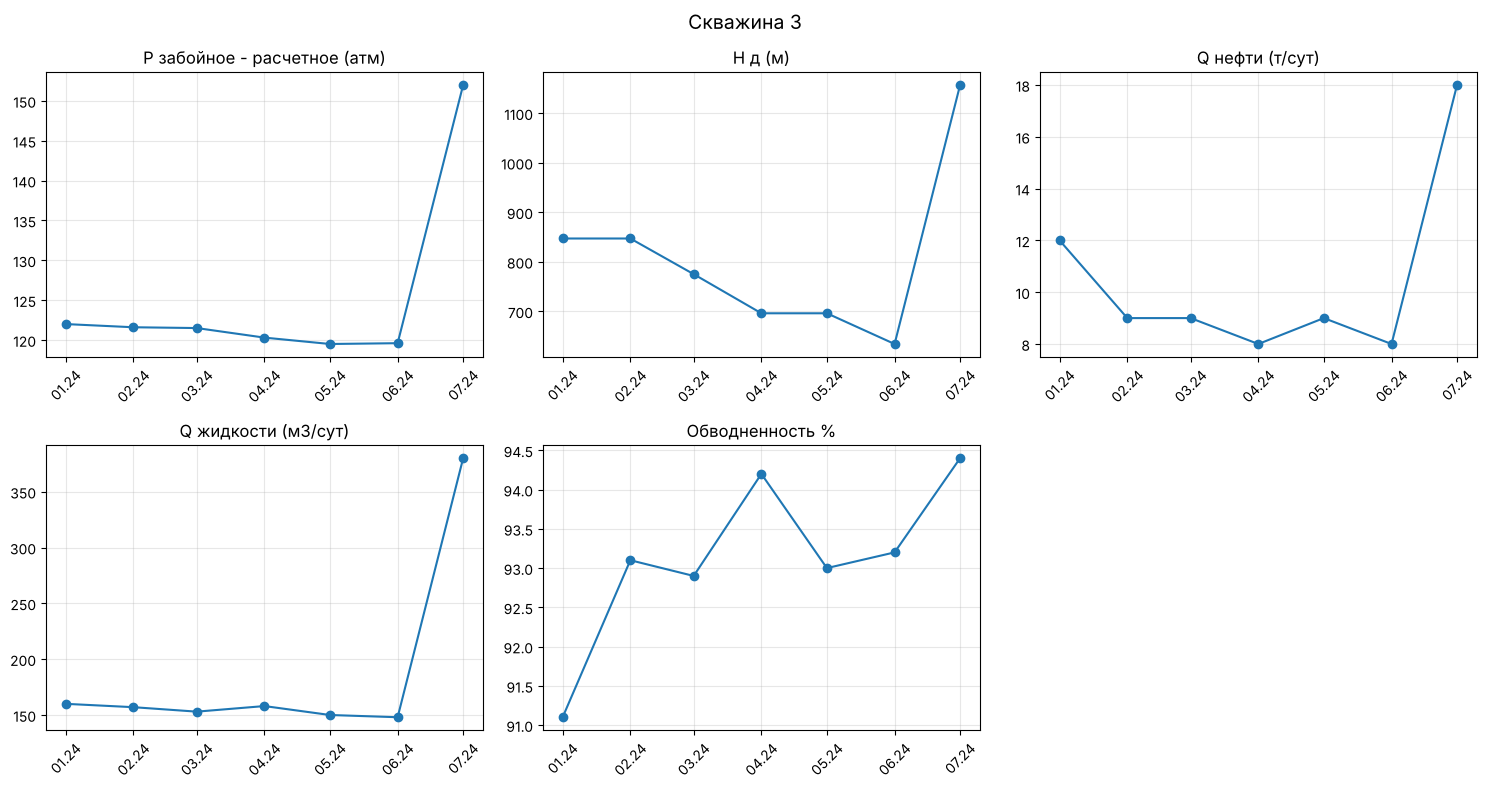

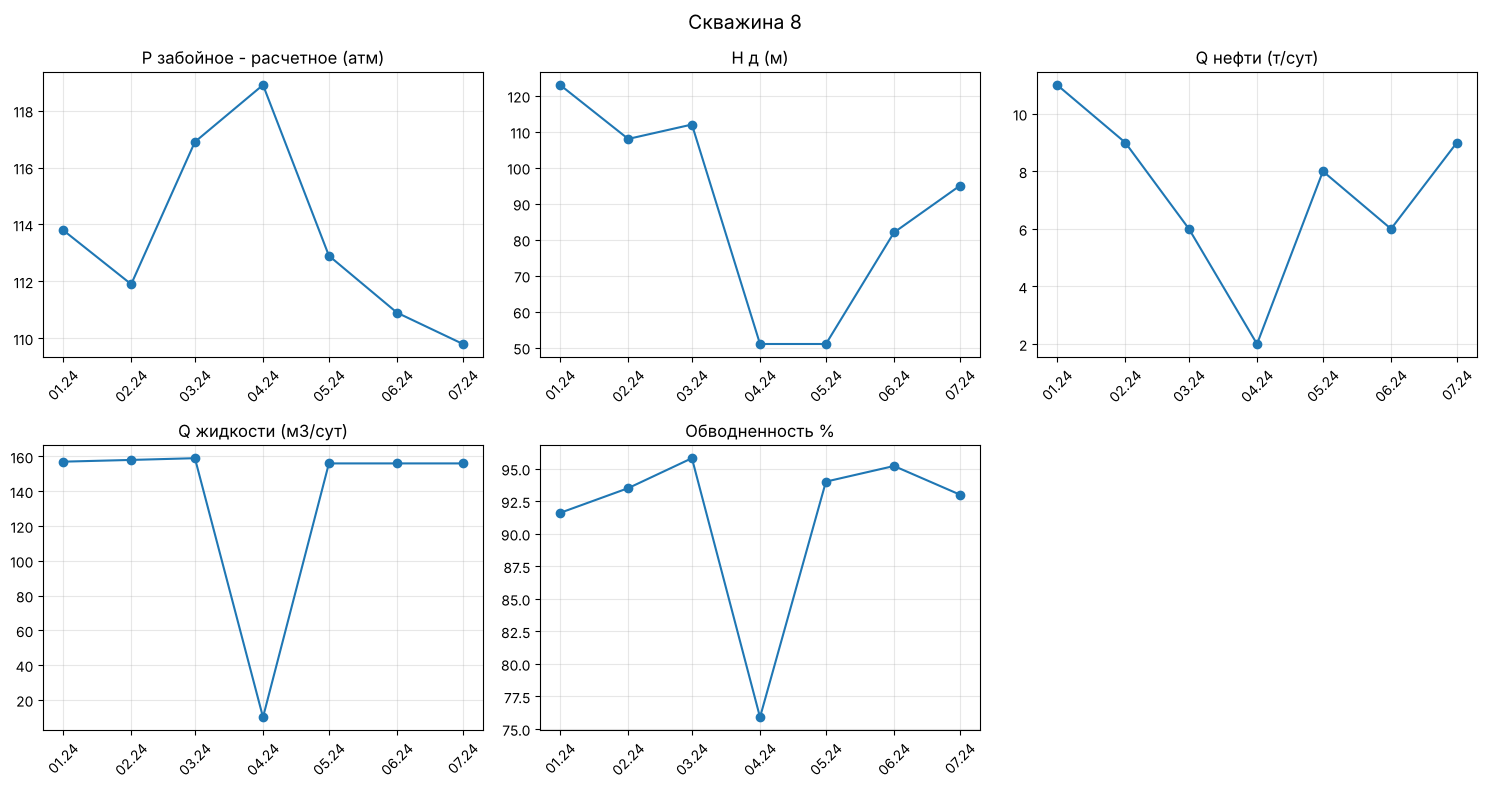

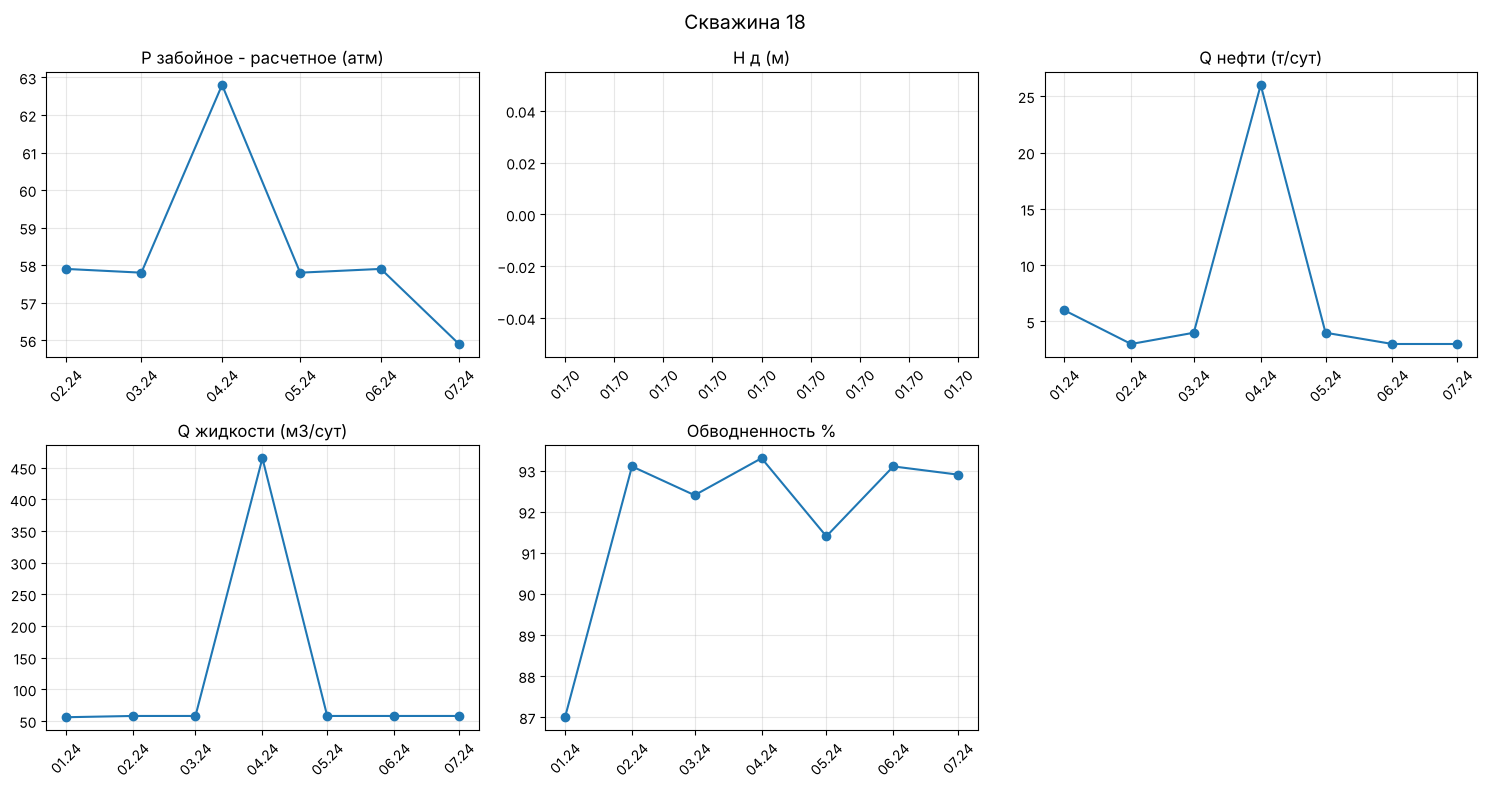

In [6]:
plt.rcParams['font.size'] = 10

def plot_well(d, well):
    """Графики всех параметров одной скважины на одной фигуре."""
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    axes = axes.ravel()
    for ax, col in zip(axes, NUM_COLS):
        ax.plot(d['Дата'], d[col], marker='o', linestyle='-', color='tab:blue')
        ax.set_title(col)
        ax.grid(True, alpha=0.3)
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%m.%y'))
        ax.tick_params(axis='x', rotation=45)
    axes[-1].axis('off')  # шестая ячейка не нужна
    fig.suptitle(f'Скважина {well}', fontsize=14)
    fig.tight_layout()
    plt.show()

for w, d in wells.items():
    plot_well(d, w)

## Задание 2. Расчётные показатели

Для каждой скважины добавьте колонки и постройте по ним графики:

- **Q воды** (м³/сут) = Q жидкости − Q нефти / ρн;
- **ВНФ** (водонефтяной фактор) = Q воды / (Q нефти / ρн);
- **накопленная добыча** нефти (т) и жидкости (м³): суточный дебит × число дней в месяце (`Дата.dt.days_in_month`), затем `cumsum()`;
- **темп падения добычи нефти**, % к предыдущему месяцу.

Кратко опишите, что показывают тренды.

In [ ]:
# ваш код здесь


## Задание 3. Сравнение скважин

- Для каждого параметра постройте один график, на котором все скважины разными цветами (с легендой).
- Посчитайте суммарную добычу нефти и жидкости по месторождению (по выбранным скважинам) по месяцам и постройте график.
- Сделайте сводную таблицу: среднее, min, max по каждому параметру для каждой скважины, доля каждой скважины в суммарной добыче нефти.
- Сделайте вывод: какая скважина самая продуктивная, у какой быстрее растёт обводнённость.

In [ ]:
# ваш код здесь


# Прогнозирование параметров

## Пример с линейной регрессией

In [9]:
# выберем скважину и параметр для предсказания
well = '3'
param = 'Обводненность %'

d = wells[well].dropna(subset=[param])

X = d[['t']]   # номер месяца от начала ряда
y = d[param]

Скважина 3. Прогноз «Обводненность %» на 08.2024: 94.6


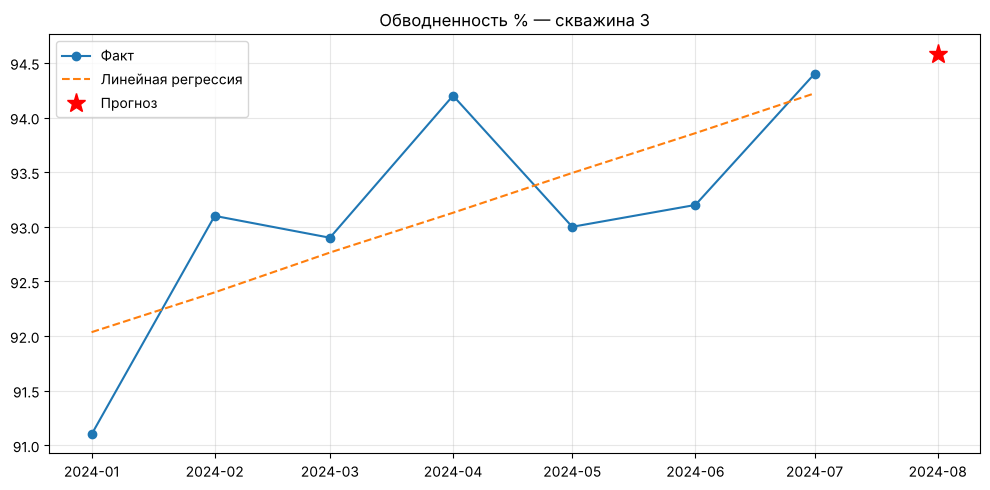

In [ ]:
# возьмем модель линейной регрессии из sklearn
model = LinearRegression()
model.fit(X, y)

# прогноз на следующий месяц после последнего в данных
next_date = d['Дата'].max() + pd.DateOffset(months=1)
X_next = pd.DataFrame({'t': [d['t'].max() + 1]})
pred = model.predict(X_next)[0]
print(f'Скважина {well}. Прогноз «{param}» на {next_date:%m.%Y}: {pred:.1f}')

# факт + линия регрессии + прогноз
plt.figure(figsize=(10, 5))
plt.plot(d['Дата'], y, 'o-', label='Факт')
plt.plot(d['Дата'], model.predict(X), '--', label='Линейная регрессия')
plt.plot(next_date, pred, 'r*', markersize=14, label='Прогноз')
plt.title(f'{param} — скважина {well}')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

## Задание 4. Другие регрессии и выбор лучшей модели

- Возьмите **минимум 2 другие регрессии** из scikit-learn (например: `Ridge`, полиномиальная — `PolynomialFeatures` + `LinearRegression`, `DecisionTreeRegressor`, `RandomForestRegressor`, `SVR`, `KNeighborsRegressor`).
- Разбейте ряд **по времени**: последние 3–4 месяца — тест, остальное — обучение (данные не перемешивать!).
- Посчитайте метрики MAE, RMSE, MAPE для линейной регрессии и ваших моделей. Добавьте базовый прогноз «значение = как в прошлом месяце» и сравните с ним.
- Сведите результаты в таблицу, выберите лучшую модель и обоснуйте выбор.
- Лучшей моделью сделайте прогноз на следующий месяц после последнего для каждой скважины; постройте график «факт + прогноз».

In [ ]:
# ваш код здесь


## Задание 5. Многофакторная модель

До этого прогноз строился только по номеру месяца. Постройте модель, которая предсказывает **Q нефти** следующего месяца по нескольким признакам:

- лаги (значения прошлого месяца, `shift(1)`): Q нефти, Q жидкости, обводнённость;
- P забойное, Н д (решите, что делать с пропусками у скважин с пакером);
- при желании — номер месяца `t` и номер скважины (one-hot), чтобы обучаться сразу на всех скважинах.

Оцените модель на тех же тестовых месяцах, что и в Задании 4, и сравните метрики. Покажите важность признаков (коэффициенты или `feature_importances_`) и объясните, какие параметры сильнее всего влияют на добычу.

In [ ]:
# ваш код здесь


## Задание 6. Кластеризация скважин

С помощью `KMeans` (scikit-learn) сгруппируйте скважины по характеру работы:

- для каждой скважины соберите признаки: средние Q нефти, Q жидкости, обводнённость, P забойное, наклон тренда обводнённости и т.п.;
- нормализуйте признаки (`StandardScaler`);
- если скважин мало (3–4), кластеризуйте не скважины целиком, а **помесячные состояния** скважин (каждая строка таблицы — точка);
- подберите число кластеров (метод локтя или `silhouette_score`), визуализируйте результат на диаграмме рассеяния;
- опишите, чем кластеры отличаются друг от друга.

In [ ]:
# ваш код здесь
